In [58]:
# importing essential libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

<p style="color:red">Task for this notebook</p>

- [ ] Move `_posts`, `_images` and `_comments` markdown information (see Step 1) into README.md (explain what each datasets does and what their features are). Check `III. METHODOLOGY / PROPOSED METHOD` 3) Dataset Output Format for more info

In [59]:
# load dataset
D_westernu_posts = pd.read_csv("../../dataset/reddit_data/WesternU_posts.csv")
D_westernu_images = pd.read_csv("../../dataset/reddit_data/WesternU_images.csv")
D_westernu_comments = pd.read_csv("../../dataset/reddit_data/WesternU_comments.csv")

## Step 1 (Data Cleaning)
To make sense of our dataset (what is important and what is not), I have labelled them:

### _posts datasets
This datasets gets all the main posts made by a given user in a subreddit

| Column                         | Description                                      |
|--------------------------------|--------------------------------------------------|
| **subreddit**                  | Name of the current subreddit                    |
| **post_id**                    | Posts ID                                         |
| **post_title**                 | Title of post                                    |
| **post_score**                 | Posts net score (upvotes - downvotes)            |
| **post_url**                   | Direct reddit posts URL                          |
| **post_content_url**           | If image exists, links directly to post image    |
| **post_text**                  | Text contents of the post                        |
| **timestamp**                  | UTC timestamp                                    |
| **post_upvote_ratio**          | Upvote to downvote ratio                         |
| **post_ups**                   | Current post upvotes                             |
| **post_total_awards_received** | Post awards received                             |
| **post_link_flair_text**       | Post flairs (categories)                         |
| **post_author**                | Post author username                             |
| **post_num_comments**          | Post number of comments                          |
| **has_images**                 | Boolean if post have image or not                |
| **num_images**                 | Number of images the post contains (gallery)     |
| **is_gallery**                 | Boolean if gallery is exist                      |
| **content_type**               | Describes which format the content is            |


### _images datasets
This dataset gets the images made by any user in a subreddit (comments and posts)

| Column                         | Description                                             |
|--------------------------------|---------------------------------------------------------|
| **subreddit**                  | Name of the current subreddit                           |
| **post_id**                    | Posts ID                                                |
| **comment_id**                 | Comment_ID                                              |
| **image_index**                | Current index of the image (gallery style)              |
| **image_url**                  | Direct image URL                                        |
| **image_source**               | Indicates where image came from (comment, gallery, post |
| **image_type**                 | Indicates if its embedded, gallery or direct            |
| **media_id**                   | Media ID                                                |


### _comments datasets
This datasets gets all the comments from a parent post and their replies below it

| Column                         | Description                                      |
|--------------------------------|--------------------------------------------------|
| **post_id**                    | Posts ID                                         |
| **comment_id**                 ||
| **comment_text**               ||
| **comment_score**              ||
| **comment_author**             ||
| **comment_created_utc**        ||
| **parent_id**                  ||
| **reply_to_id**                ||
| **comment_sentiment**          ||
| **has_images**                 ||
| **num_images**                 ||
| **image_urls**                 ||
| **subreddit**                  ||


In [60]:
# note to self, might wanna delete post_content_url as it serves not much of a purpose, only creates dupplicate
# links for non image posts and gallery links diretly to the post itself

In [61]:
print(D_westernu_posts.isna().sum()) # show missing values
display(D_westernu_posts.head())

subreddit                      0
post_id                        0
post_title                     0
post_score                     0
post_url                       0
post_content_url               0
post_text                      8
timestamp                      0
post_upvote_ratio              0
post_ups                       0
post_total_awards_received     0
post_link_flair_text          51
post_author                    0
post_num_comments              0
has_images                     0
num_images                     0
is_gallery                     0
content_type                   0
dtype: int64


,subreddit,post_id,post_title,post_score,post_url,post_content_url,post_text,timestamp,post_upvote_ratio,post_ups,post_total_awards_received,post_link_flair_text,post_author,post_num_comments,has_images,num_images,is_gallery,content_type
0,WesternU,12p2lmp,Anyone looking for a roomie at western????,2,https://reddit.com/r/WesternU/comments/12p2lmp...,https://www.reddit.com/r/WesternU/comments/12p...,\nI’m doing med sci or health sci as an undergrad,1.681707e+09,1.0,2,0,NaN,Specific-Check7872,2,False,0,False,text
1,WesternU,12fi6k7,better pre med route 🤔,2,https://reddit.com/r/WesternU/comments/12fi6k7...,https://www.reddit.com/r/WesternU/comments/12f...,Rethinking my life choices atm\n\n[View Poll](...,1.680951e+09,1.0,2,0,NaN,Purple_Character6184,0,False,0,False,text
2,WesternU,12dvo59,western vs. usask mph?,3,https://reddit.com/r/WesternU/comments/12dvo59...,https://www.reddit.com/r/WesternU/comments/12d...,i got accepted into both usask and western mas...,1.680810e+09,1.0,3,0,NaN,OwnButterscotch4039,1,False,0,False,text
3,WesternU,12bmcep,transfer to western,1,https://reddit.com/r/WesternU/comments/12bmcep...,https://www.reddit.com/r/WesternU/comments/12b...,Interested in transferring to western engineer...,1.680622e+09,1.0,1,0,NaN,Far-Ask-9746,0,False,0,False,text
4,WesternU,11mj5tr,Do Western admissions officers care if I took ...,1,https://reddit.com/r/WesternU/comments/11mj5tr...,https://www.reddit.com/r/WesternU/comments/11m...,"Hello,\nI’m a mature student that didn’t do to...",1.678338e+09,1.0,1,0,NaN,Melodic_Rabbit7187,0,False,0,False,text


In [62]:
print(D_westernu_images.isna().sum()) # show missing values
display(D_westernu_images.head())

subreddit       0
post_id         0
image_index     0
image_url       0
image_source    0
image_type      0
media_id        1
dtype: int64


,subreddit,post_id,image_index,image_url,image_source,image_type,media_id
0,WesternU,zeig23,0,https://preview.redd.it/1in29fq6hc4a1.png?widt...,post_text,embedded_link,NaN


In [63]:
print(D_westernu_comments.isna().sum()) # show missing values
display(D_westernu_comments.head())

post_id                 0
comment_id              0
comment_text            0
comment_score           0
comment_author          0
comment_created_utc     0
parent_id               0
reply_to_id             0
comment_sentiment      47
has_images              0
num_images              0
image_urls             47
subreddit               0
dtype: int64


,post_id,comment_id,comment_text,comment_score,comment_author,comment_created_utc,parent_id,reply_to_id,comment_sentiment,has_images,num_images,image_urls,subreddit
0,12p2lmp,kvayuwc,Meee I’m probably doing health sci,1,[deleted],1.710695e+09,t3_12p2lmp,12p2lmp,NaN,False,0,NaN,WesternU
1,12p2lmp,jlprjaz,Hi,1,Purple_Character6184,1.685117e+09,t3_12p2lmp,12p2lmp,NaN,False,0,NaN,WesternU
2,12dvo59,lm2j9yu,"Congrats! May I know your stats, like gpa and ...",1,Only_Researcher6011,1.725773e+09,t3_12dvo59,12dvo59,NaN,False,0,NaN,WesternU
3,ztfu7e,lm9oi3b,I am interested in!,1,Only_Researcher6011,1.725886e+09,t3_ztfu7e,ztfu7e,NaN,False,0,NaN,WesternU
4,ztfu7e,m7hxd3l,yes,1,Eastern-State6466,1.737054e+09,t3_ztfu7e,ztfu7e,NaN,False,0,NaN,WesternU


## Step 2 (Data Explatory and feature engineering/selection)
Evidently, we see we have missing values in our dataset and comment_sentiment hasn't been labelled yet. As stated in our Phase II document, we will label them using VADER (Valence Aware Dictionary and sEntiment Reasoner) which is effective for social media text.
..
I feel its best to completely remove the null values since we have alot of datasets and imputing wouldn't make sense as we have unique ID's and since we're dealing with a human text sentimental analysis it would be in our best interest to keep the sementic meanings intact as much as possible and as early on.\
There isn't much use for feature selection as the data has been specifically currated (custom made) to serve our specific use case and there will be minimal feature engineering because reddit JSON has already organized all features into their own unique and useful columns. 

In [64]:
# Testing if VADER works
import nltk
nltk.download("vader_lexicon", quiet=True)

from nltk.sentiment.vader import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()
text = D_westernu_comments["comment_text"][0]
scores = analyzer.polarity_scores(text)

print(scores)
print(text)

{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
Meee I’m probably doing health sci


In [65]:
# Labelling sentimental scores
D_westernu_comments["sentiment_scores"] = D_westernu_comments["comment_text"].apply(lambda x: analyzer.polarity_scores(x) if isinstance(x, str) else analyzer.polarity_scores(""))
D_westernu_comments["compound"] = D_westernu_comments["sentiment_scores"].apply(lambda x: x["compound"])

D_westernu_posts["sentiment_scores"] = D_westernu_posts["post_text"].apply(lambda x: analyzer.polarity_scores(x) if isinstance(x, str) else analyzer.polarity_scores(""))
D_westernu_posts["compound"] = D_westernu_posts["sentiment_scores"].apply(lambda x: x["compound"])

In [66]:
def get_sentiment_label(compound_score):
    if compound_score >= 0.05: return "positive"
    elif compound_score <= -0.05: return "negative"
    else: return "neutral"
        
D_westernu_comments["comment_sentiment"] = D_westernu_comments["compound"].apply(get_sentiment_label)
D_westernu_posts["post_sentiment"] = D_westernu_posts["compound"].apply(get_sentiment_label)

In [67]:
pd.set_option("display.max_colwidth", None) # removes truncated text from table
display(D_westernu_comments[["comment_text","comment_sentiment","sentiment_scores","compound"]].head())
display(D_westernu_posts[["post_text","post_sentiment","sentiment_scores","compound"]].head())
pd.set_option("display.max_colwidth", 50) # goes back to normal

,comment_text,comment_sentiment,sentiment_scores,compound
0,Meee I’m probably doing health sci,neutral,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}",0.0000
1,Hi,neutral,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}",0.0000
2,"Congrats! May I know your stats, like gpa and lab experience?",positive,"{'neg': 0.0, 'neu': 0.564, 'pos': 0.436, 'compound': 0.7345}",0.7345
3,I am interested in!,positive,"{'neg': 0.0, 'neu': 0.401, 'pos': 0.599, 'compound': 0.4574}",0.4574
4,yes,positive,"{'neg': 0.0, 'neu': 0.0, 'pos': 1.0, 'compound': 0.4019}",0.4019


,post_text,post_sentiment,sentiment_scores,compound
0,\nI’m doing med sci or health sci as an undergrad,neutral,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}",0.0000
1,Rethinking my life choices atm\n\n[View Poll](https://www.reddit.com/poll/12fi6k7),neutral,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}",0.0000
2,i got accepted into both usask and western masters of public health. i’m not sure which one to choose. does anyone have any experience about either and which one would you recommend?,positive,"{'neg': 0.057, 'neu': 0.81, 'pos': 0.133, 'compound': 0.3895}",0.3895
3,Interested in transferring to western engineering from york engineering. Ive only finished first year.\n\nAny help regarding the process would be nice.,positive,"{'neg': 0.0, 'neu': 0.699, 'pos': 0.301, 'compound': 0.802}",0.8020
4,"Hello,\nI’m a mature student that didn’t do too well in high school, so now I am retaking courses at an adult school for better grades. Will this affect my chances when I go to apply in October (btw I’m applying for the collaborative nursing program with Fanshawe and Western)?",positive,"{'neg': 0.0, 'neu': 0.817, 'pos': 0.183, 'compound': 0.8225}",0.8225


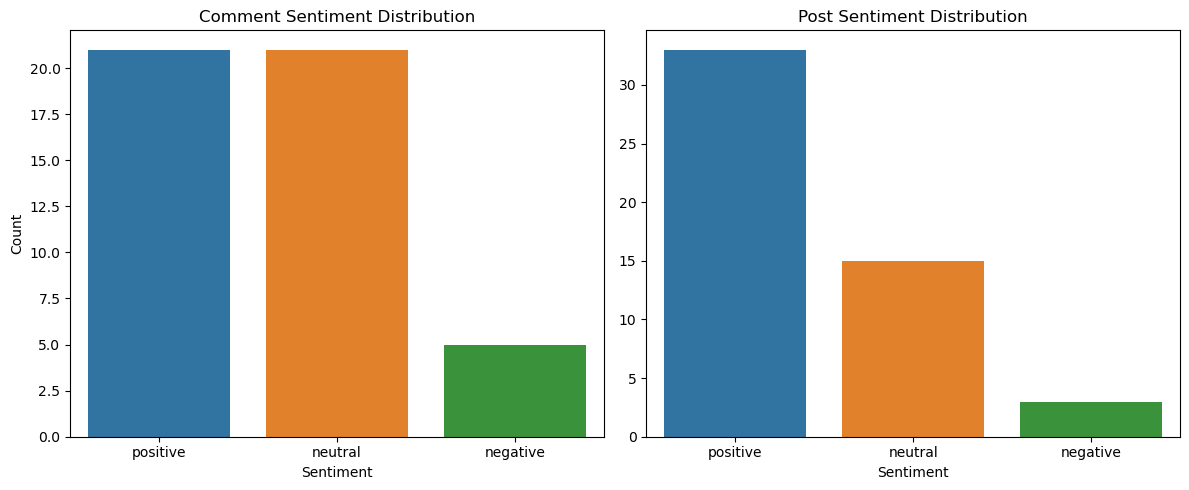

In [68]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))

sns.countplot(
    data=D_westernu_comments,
    x="comment_sentiment",
    order=["positive","neutral","negative"],
    ax=ax[0]
)
ax[0].set_title("Comment Sentiment Distribution")
ax[0].set_xlabel("Sentiment")
ax[0].set_ylabel("Count")

sns.countplot(
    data=D_westernu_posts,
    x="post_sentiment",
    order=["positive","neutral","negative"],
    ax=ax[1]
)
ax[1].set_title("Post Sentiment Distribution")
ax[1].set_xlabel("Sentiment")
ax[1].set_ylabel("")

plt.tight_layout()
plt.show()

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


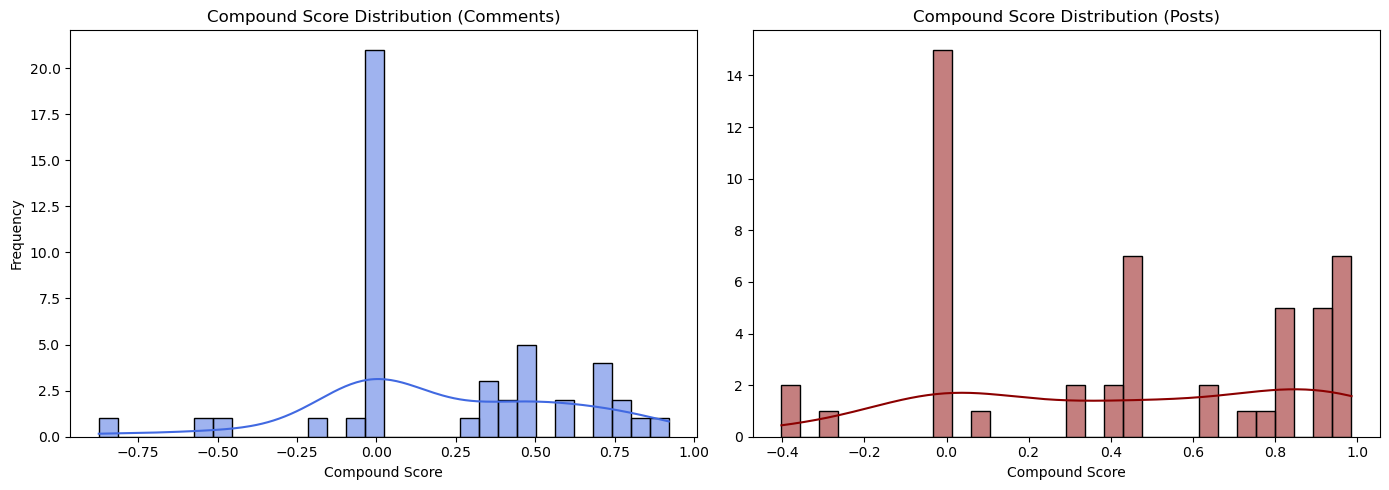

In [69]:
fig, ax = plt.subplots(1, 2, figsize=(14,5))

sns.histplot(
    D_westernu_comments["compound"],
    bins=30, kde=True, color="royalblue", ax=ax[0]
)
ax[0].set_title("Compound Score Distribution (Comments)")
ax[0].set_xlabel("Compound Score")
ax[0].set_ylabel("Frequency")

sns.histplot(
    D_westernu_posts["compound"],
    bins=30, kde=True, color="darkred", ax=ax[1]
)
ax[1].set_title("Compound Score Distribution (Posts)")
ax[1].set_xlabel("Compound Score")
ax[1].set_ylabel("")

plt.tight_layout()
plt.show()

## Step X (Apply changes to all dataset)
We'll be applying all the changes made to our one subreddit dataset (WesternU)

In [70]:
project_dir = os.getcwd()
data_path = os.path.join(project_dir, "../../", "dataset", "reddit_data")
data_path = os.path.abspath(data_path)

# show working path
print("Data folder path:", data_path)

Data folder path: /Users/jiwonlee/ds3000/GroupProject/dataset/reddit_data


In [71]:
datasets = {} # dictionary to store all loaded datasets

# Loop over all files in the folder
for file in os.listdir(data_path):
    if file.endswith(".csv"):
        name = file.replace(".csv", "")
        df = pd.read_csv(os.path.join(data_path, file))
        datasets[name] = df

print(f"Loaded datasets: {list(datasets.keys())}")

for name, df in datasets.items():
    if name.endswith("_posts"):
        text_col = "post_text"
        sentiment_col = "post_sentiment"
    elif name.endswith("_comments"):
        text_col = "comment_text"
        sentiment_col = "comment_sentiment"
    else:
        continue  # skip any files not following the naming convention

    # Sentiment scoring
    df["sentiment_scores"] = df[text_col].apply(lambda x: analyzer.polarity_scores(x) if isinstance(x, str) else analyzer.polarity_scores(""))
    df["compound"] = df["sentiment_scores"].apply(lambda x: x["compound"])
    df[sentiment_col] = df["compound"].apply(get_sentiment_label)

    # Update the dataset in the dictionary
    datasets[name] = df

Loaded datasets: ['WesternU_posts', 'WesternU_comments', 'WesternU_comments_bert_results', 'WesternU_images', 'WesternU_comments_vader_sentiment']


In [72]:
# Save the processed datasets into a path to be used in other notebooks
processed_path = os.path.join(project_dir, "..", "data", "processed")
os.makedirs(processed_path, exist_ok=True)

for name, df in datasets.items():
    df.to_csv(os.path.join(processed_path, f"{name}_processed.csv"), index=False)

print("Datasets saved")

Datasets saved


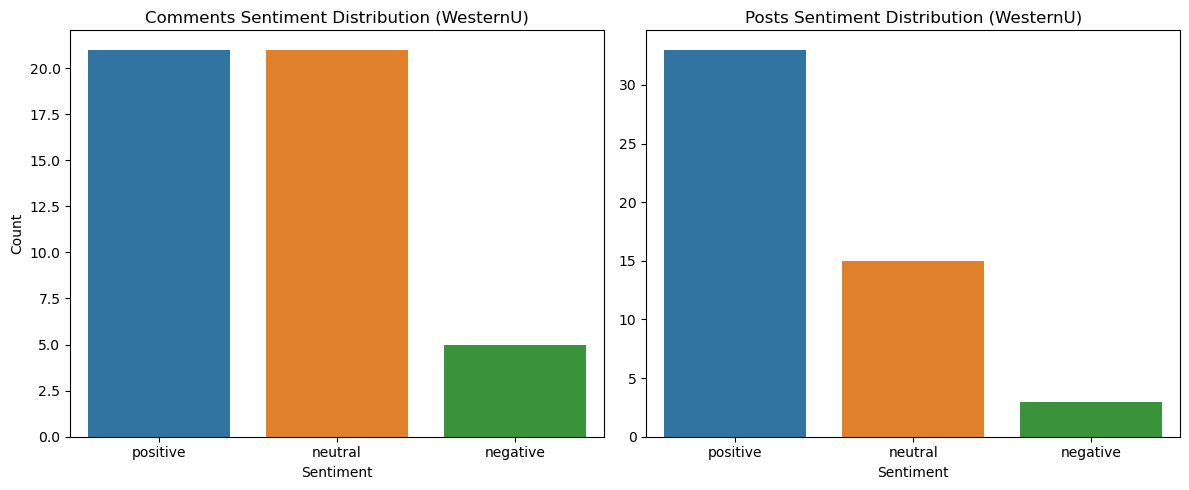

In [73]:
for thread_name in set(k.split("_")[0] for k in datasets.keys()):
    fig, ax = plt.subplots(1, 2, figsize=(12,5))

    for i, suffix in enumerate(["comments", "posts"]):
        dataset_name = f"{thread_name}_{suffix}"
        if dataset_name not in datasets:
            continue

        df = datasets[dataset_name]
        sentiment_col = "comment_sentiment" if suffix=="comments" else "post_sentiment"

        sns.countplot(
            data=df,
            x=sentiment_col,
            order=["positive","neutral","negative"],
            ax=ax[i]
        )
        ax[i].set_title(f"{suffix.capitalize()} Sentiment Distribution ({thread_name})")
        ax[i].set_xlabel("Sentiment")
        ax[i].set_ylabel("Count" if suffix=="comments" else "")

    plt.tight_layout()
    plt.show()